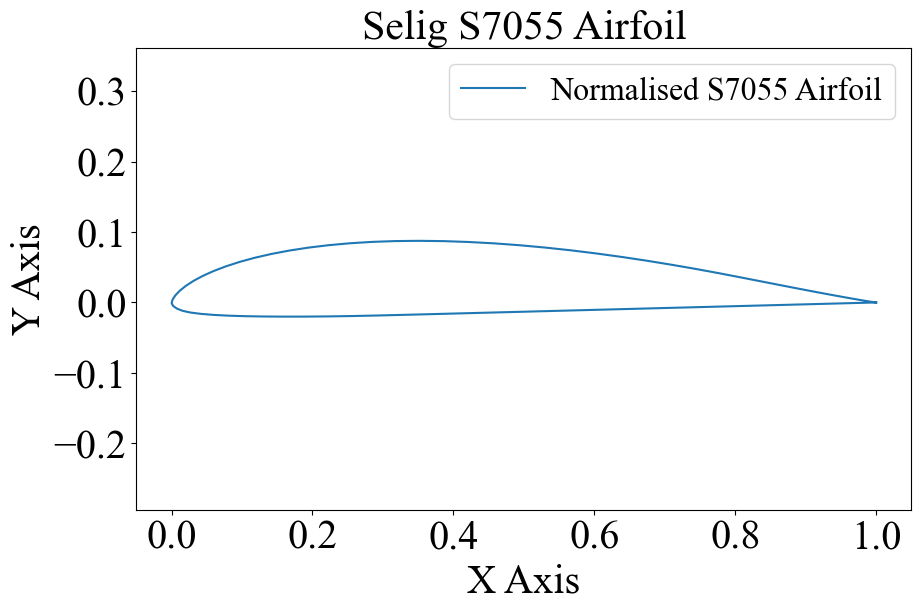

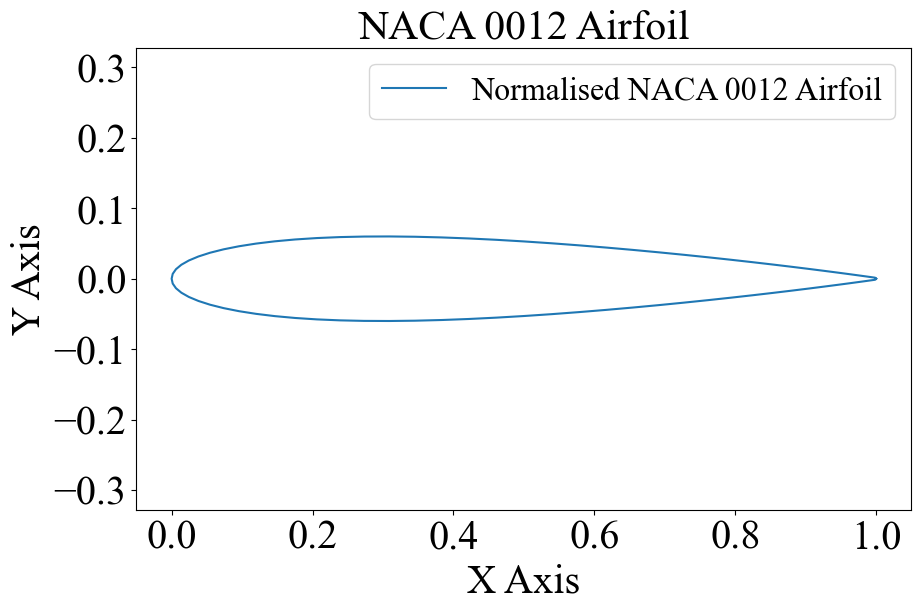

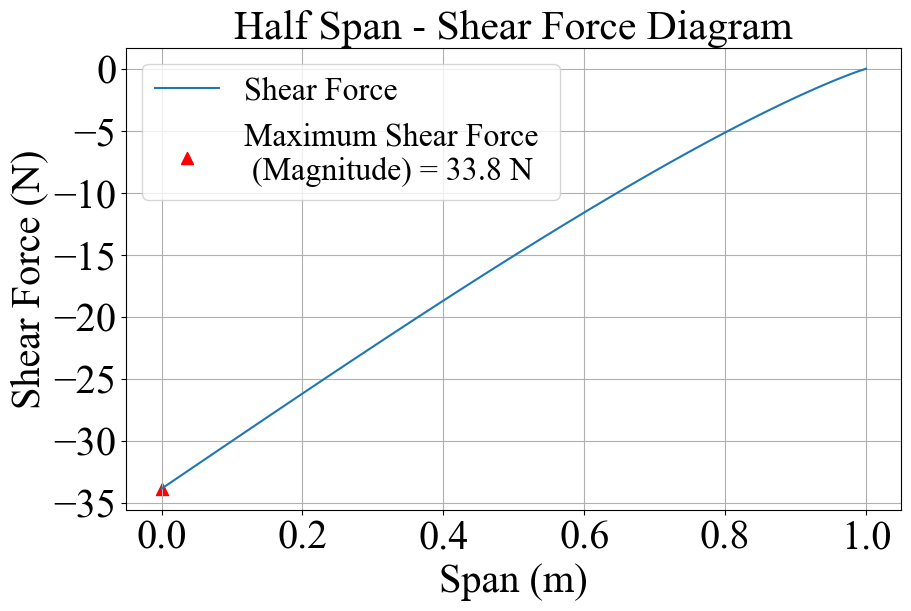

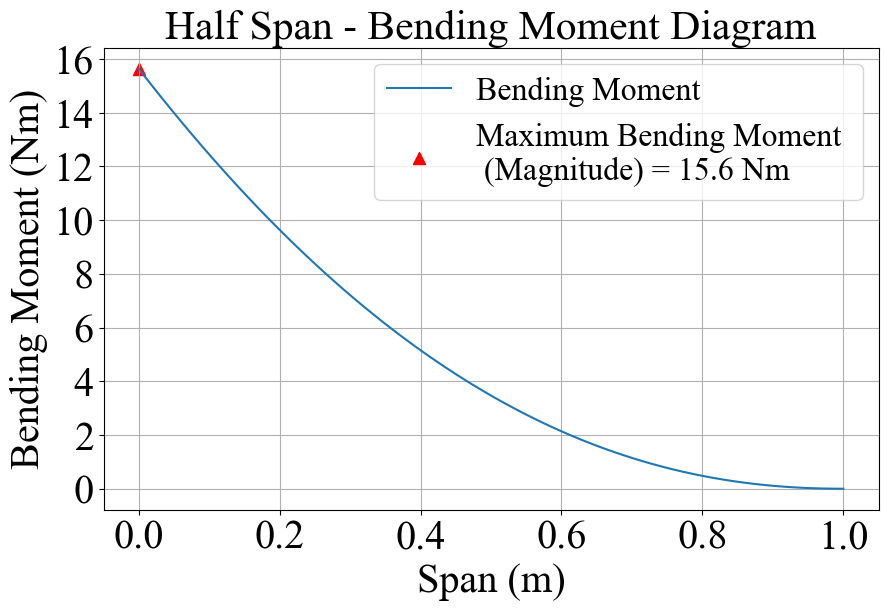

Ixx (skin) = 2.99e-08 m^4
Thickness of Airfoil (max) = 27.8 mm
Stress (Design, Skin) = 8.04 MPa
Ixx (required, max) = 2.71e-08 m^4


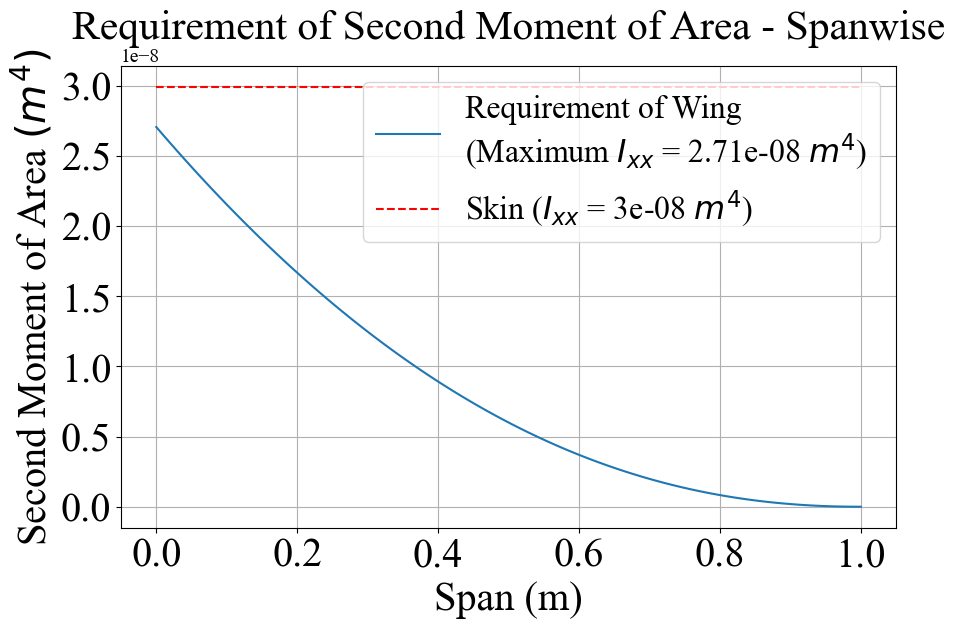


Ixx (spar, required, Al1100) = 2.71e-08 m^4
Ixx (spar, required, Al6061-T6) = 9.31e-09 m^4
Ixx (spar) = 9.54e-09 m^4


In [85]:
### Author: Mahesh ###

import numpy as np
import matplotlib.pyplot as plt
plt.rc('font', size=25)

text_size = 28
label_size = text_size + 1
Title_size = text_size + 2


# Part 0
s7055_norm = np.loadtxt('s7055.dat')
naca0012_norm = np.loadtxt('naca0012.dat')      # Airfoil has Trailing Edge Gap

plt.figure(figsize=(10, 6))
plt.plot(s7055_norm[:, 0], s7055_norm[:, 1], label="Normalised S7055 Airfoil")
plt.axis('equal')
plt.title("Selig S7055 Airfoil", fontsize=Title_size)
plt.xlabel('X Axis', fontsize=label_size)
plt.ylabel('Y Axis', fontsize=label_size)
plt.xticks(fontsize=label_size)
plt.yticks(fontsize=label_size)
plt.legend(fontsize=text_size-5)
plt.savefig("s7055_airfoil.png", dpi=300, bbox_inches="tight",pad_inches=0.1)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(naca0012_norm[:, 0], naca0012_norm[:, 1], label="Normalised NACA 0012 Airfoil")
plt.axis('equal')
plt.title("NACA 0012 Airfoil", fontsize=Title_size)
plt.xlabel('X Axis', fontsize=label_size)
plt.ylabel('Y Axis', fontsize=label_size)
plt.xticks(fontsize=label_size)
plt.yticks(fontsize=label_size)
plt.legend(fontsize=text_size-5)
plt.savefig("naca0012_airfoil.png", dpi=300, bbox_inches="tight",pad_inches=0.1)
plt.show()

# Part 1

# Wing Parameters
b = 2
S = 0.53
W = 6.9*9.81

# Evaluating Chord for Elliptical and Rectangular Wing
x = np.linspace(0, b/2, 100)

c_elliptical = 4*S*np.sqrt(1 - (2*x/b)**2)/(np.pi*b)
c_rectangular = 0.265*np.ones_like(x)

# Evaluating Schrenk Equivalent Chord
c_schrenk = (c_rectangular + c_elliptical)/2

# Evaluating Lift Distribution for Schrenk and Elliptical Lift Distribution
k = (W/2)/np.trapz(y=c_schrenk, x=x)

q_schrenk = k*c_schrenk
q_elliptical = k*c_elliptical
q_rectangular = k*c_rectangular


# # Lift Distribution Plot
# plt.figure(figsize=(10, 6))
# plt.plot(x, q_schrenk, label="Schrenk Approximated")
# plt.plot(x, q_elliptical, label="Elliptical")
# plt.plot(x, q_rectangular, label="Rectangular")
# plt.title("Half Span - Lift Distribution")
# plt.ylabel("Distributed Load (N/m)")
# plt.xlabel("Span (m)")
# plt.grid()
# plt.legend()
# plt.xlim(0, 1)
# plt.show()




# Calculating Shear Force and Bending Moment
M = np.zeros_like(q_schrenk)
V = np.zeros_like(q_schrenk)

for i in range(len(M)):
    V[i] = -np.trapz(q_schrenk[i:], x=x[i:])
    M[i] = np.trapz(q_schrenk[i:]*(x[i:] - x[i]), x=x[i:])

np.savetxt("spanwise_shear_force.csv", np.column_stack((x, V)), delimiter=',')


# Shear Force Diagram
plt.figure(figsize=(10, 6))
plt.plot(x, V, label="Shear Force")
idx_Vmax = np.argmax(np.abs(V))
plt.scatter(idx_Vmax, -np.max(np.abs(V)), marker='^', c='r', s=75, label=f"Maximum Shear Force \n (Magnitude) = {max(abs(V)):.3g} N")
plt.title("Half Span - Shear Force Diagram", fontsize=Title_size)
plt.xticks(fontsize=label_size)
plt.yticks(fontsize=label_size)
plt.xlabel("Span (m)", fontsize=label_size)
plt.ylabel("Shear Force (N)", fontsize=label_size)
# plt.xlim(0, 1)
plt.legend(fontsize=text_size-5)
plt.grid()
plt.savefig("shear_force_diagram.png", dpi=300, bbox_inches="tight")
plt.show()


# Bending Moment Diagram
plt.figure(figsize=(10, 6))
plt.plot(x, M, label="Bending Moment")
idx_Mmax = np.argmax(M)
plt.scatter(idx_Mmax, np.max(M), marker='^', c='r', s=75, label=f"Maximum Bending Moment \n (Magnitude) = {max(abs(M)):.3g} Nm")
plt.title("Half Span - Bending Moment Diagram", fontsize=Title_size)
plt.xlabel("Span (m)", fontsize=label_size)
plt.ylabel("Bending Moment (Nm)", fontsize=label_size)
plt.xticks(fontsize=label_size)
plt.yticks(fontsize=label_size)
# plt.xlim(0, 1)
plt.legend(fontsize=text_size-5)
plt.grid()
plt.savefig("bending_moment_diagram.png", dpi=300, bbox_inches="tight")
plt.show()



# Part 2

skin_thickness = 5e-4
chord = 0.265

s7055 = np.loadtxt('s7055.dat')*chord     # Includes Trailing Edge Duplicate

s7055_dl = np.linalg.norm(s7055[:-1, :] - s7055[1:, :], axis=1)
s7055_midpt = (s7055[:-1, :] + s7055[1:, :])/2


# Idealizing skin as Mass Lumps
dA_lump = s7055_dl*skin_thickness
A_skin = np.sum(dA_lump)

y_centroid = np.sum(s7055_midpt[:, 1]*dA_lump)/A_skin
Ixx_skin = np.sum((s7055_midpt[:, 1] - y_centroid)**2*dA_lump)
print(f"Ixx (skin) = {Ixx_skin:.3g} m^4")

# Airfoil Plot (Coordinates, Mid Points & Neutral Axis)
# plt.figure(figsize=(10, 6))
# plt.plot(s7055[:, 0], s7055[:, 1], label="Airfoil Coordinates")
# plt.scatter(s7055_midpt[:, 0], s7055_midpt[:, 1], s=3, label="Panel Midpoint")
# plt.hlines(y=y_centroid, xmin=0, xmax=chord, linestyle="--", color='r', label="Neutral Axis")
# plt.title("Airfoil Coordinates")
# plt.xlabel('X Axis')
# plt.ylabel('Z Axis')
# plt.legend()
# plt.axis('equal')
# plt.show()


# Part 3

# Input Parameters
stress_yield_Al6061 = 276*1e6  # Material: Al6061-T6
stress_yield_Al1100 = 95*1e6   # Material: Al1100-H14
n_fos = 1.5
n_vn = 3.5
n_fatigue = 1.5
k_stress_conc_factor = 1.5

airfoil_max_thickness = chord*0.105     # 10.5% Chord
print(f"Thickness of Airfoil (max) = {airfoil_max_thickness*1e3:.3g} mm")
M_root = max(abs(M))
stress_design_Al1100 = stress_yield_Al1100/(n_fos*n_vn*n_fatigue*k_stress_conc_factor)
print(f"Stress (Design, Skin) = {stress_design_Al1100*1e-6:.3g} MPa")

Ixx_required_Al1100 = (M*airfoil_max_thickness/2)/stress_design_Al1100
print(f"Ixx (required, max) = {np.max(Ixx_required_Al1100):.3g} m^4")

# Plots of Second Moment of Area
plt.figure(figsize=(10, 6))
plt.plot(x, Ixx_required_Al1100, label="Requirement of Wing\n(Maximum $I_{xx}$ = "+f"{np.max(Ixx_required_Al1100):.3g} $m^4$)")
plt.hlines(y=Ixx_skin, xmin=0, xmax=b/2, linestyle="--", color='r', label="Skin ($I_{xx}$ = "+f"{Ixx_skin:.1g} $m^4$)")
plt.title("Requirement of Second Moment of Area - Spanwise", fontsize=Title_size)
plt.ylabel("Second Moment of Area $(m^4)$", fontsize=label_size)
plt.xlabel("Span (m)", fontsize=label_size)
plt.xticks(fontsize=label_size)
plt.yticks(fontsize=label_size)
plt.grid()
plt.legend(fontsize=text_size-5)
plt.savefig("second_moment_of_area_requirement.png", dpi=300, bbox_inches="tight")
plt.show()

Ixx_required_Al6061 = np.max(Ixx_required_Al1100)*stress_yield_Al1100/stress_yield_Al6061

def Ixx_Cs(web_height, flange_length, section_thickness):
    Ixx_web_Cs = section_thickness*web_height**3/12
    Ixx_flange_Cs = flange_length*section_thickness**3/12 + flange_length*section_thickness*(web_height/2)**2

    return Ixx_web_Cs + Ixx_flange_Cs*2

Ixx_spar = Ixx_Cs(airfoil_max_thickness, 20e-3, 1e-3)
print()
print(f"Ixx (spar, required, Al1100) = {np.max(np.abs(Ixx_required_Al1100)):.3g} m^4")
print(f"Ixx (spar, required, Al6061-T6) = {Ixx_required_Al6061:.3g} m^4")
print(f"Ixx (spar) = {Ixx_spar:.3g} m^4")

# plt.figure(figsize=(10, 6))
# plt.plot(x, np.where(Ixx_required - Ixx_skin > 0, Ixx_required - Ixx_skin, 0))
# plt.title("Spar - Second Moment of Area (Requirement)")
# plt.ylabel("Second Moment of Area $(m^4)$")
# plt.xlabel("Span (m)")
# plt.grid()
# plt.show()

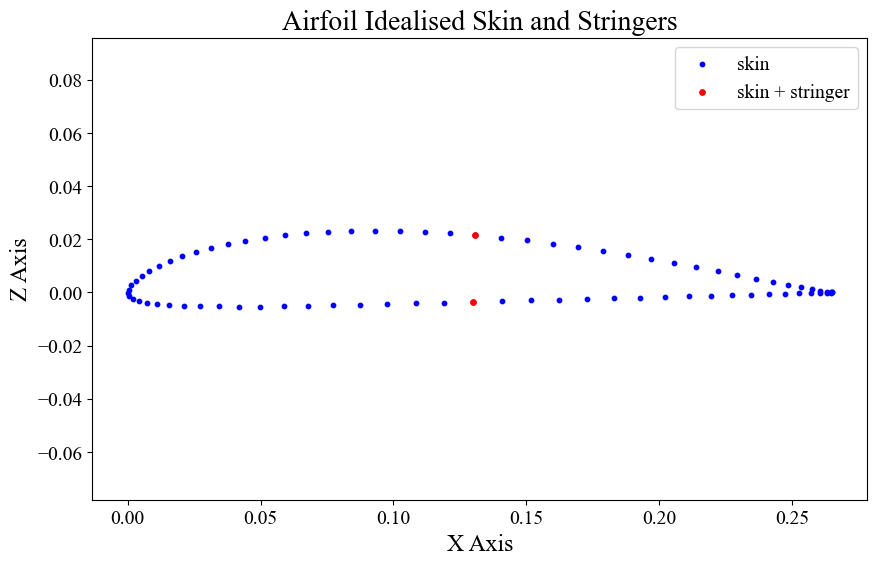

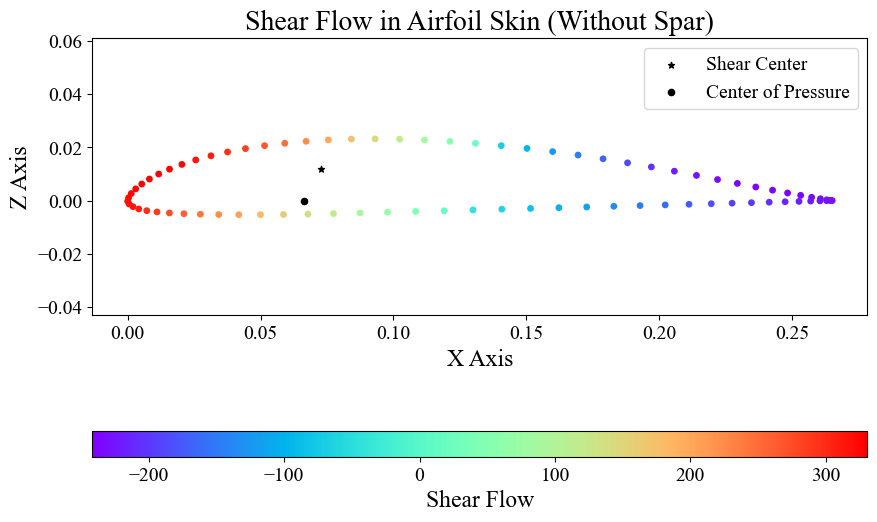

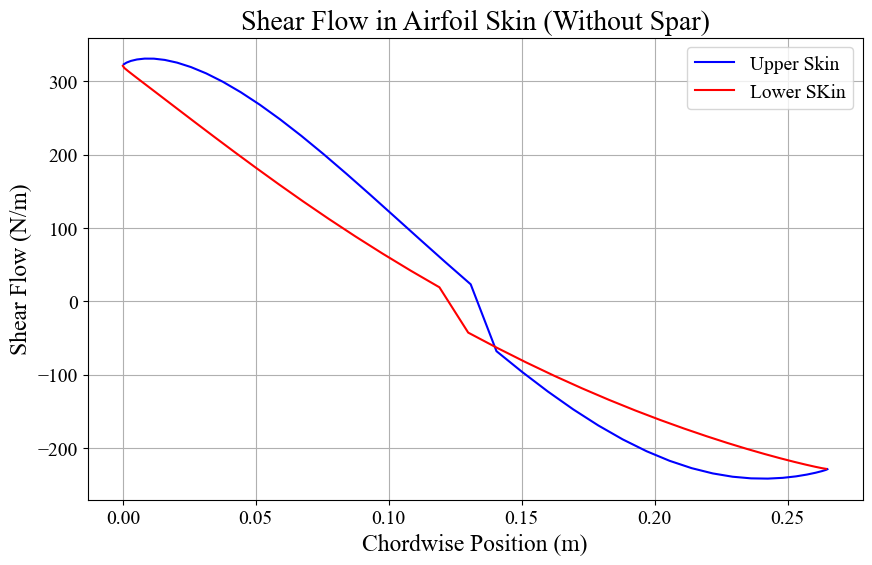

Critical Buckling Load per unit Area (Pcr) = 8.3e+05 Pa
Maximum Shear Stress in the selected Panel (tau) = 4.83e+05 Pa
Selected Panel doesn't Buckle


In [49]:
### Author: Mahesh ###

import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
plt.rc('font', size=16)
np.set_printoptions(precision=8)


# import sys
# sys.path.append('/content/drive/MyDrive/ShunkWorks')
# from week1_sd import chord, s7055, skin_thickness, M, V

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

# s7055: Airfoil Coordinates with TE Duplicated
# Note: x is chordwise, y is spanwise, z is thickness axis
# Note: sk(skin), st(stringers), sp(spar), b(boom)
# Mx is the Bending Moment on the Wing, Mz = 0
# Skin is present in the span range of 150 - 1000mm (from Midspan only)
# Booms carry Axial Stress along their longitudinal direction

# q0: Open Section Shear Flow
# qs0: Closing Shear Flow
# q: Total Shear Flow


# Airfoil
idx_TE = 0
idx_LE = 42
n_airfoil_pts = s7055.shape[0] - 1

s7055_u = s7055[:idx_LE + 1, :]
s7055_u = np.flip(s7055_u, axis=0)  # From LE to TE
s7055_l = s7055[idx_LE:, :]         # From LE to TE

s7055_mpt = (s7055[:-1, :] + s7055[1:, :])/2    # From TE to LE to TE

# Length Calculations
s7055_u_dl = np.linalg.norm(s7055_u[:-1, :] - s7055_u[1:, :], axis=1)
s7055_u_len = np.sum(s7055_u_dl)
s7055_l_dl = np.linalg.norm(s7055_l[:-1, :] - s7055_l[1:, :], axis=1)
s7055_l_len = np.sum(s7055_l_dl)
s7055_dl = np.linalg.norm(s7055[:-1, :] - s7055[1:, :], axis=1)
# print(f"Length Check: {np.sum(s7055_dl) - s7055_l_len - s7055_u_len}")

dA_sk = s7055_dl*skin_thickness
A_sk = np.sum(dA_sk)

# Data/Calculation
max_thickness_fraction = 0.105
sp_xloc = 0.3174*chord    # From Airfoil Data (Using XFLR5)
sp_thickness = 1e-3       # 1mm (C Section, Web placed at Max Thickness)
sp_flange_length = 20e-3  # 20mm
sp_web_height = max_thickness_fraction*chord

st_thickness = 0.5e-3 # 0.5mm (L shaped stringer)
st_length = 20e-3     # Total length of L shape
st_area = st_length*st_thickness


tD = skin_thickness         # 0.5mm
xcp = chord/4               # From the LE

# Bending Moment and Shear Force Calculation
y = np.linspace(0, 1, len(V))
Mx_y = CubicSpline(y, M)
Vz_y = CubicSpline(y, V)

Case = "1"

if Case == "1":
    # Case 1 (Without Spar, Non Aileron Section)
    # Span Range (from Midplane): 550 - 700mm & 950 - 1000mm
    yi_c1 = 0.55

    # Stringers Location
    st_xloc_est = np.array([0.5])*chord
    n_st = 2*st_xloc_est.shape[0]

    idx_u = np.argmin(np.abs(s7055_u[:, 0] - st_xloc_est[0]))
    idx_l = np.argmin(np.abs(s7055_l[:, 0] - st_xloc_est[0]))
    idx_l_s7055 = idx_l + idx_LE
    idx_u_s7055 = idx_LE - idx_u
    st_xzloc = np.vstack((s7055[idx_u_s7055, :], s7055[idx_l_s7055, :]))

    ### Plot Check
    plt.figure(figsize=(10, 6))
    # plt.plot(s7055_u[:, 0], s7055_u[:, 1])
    # plt.plot(s7055_l[:, 0], s7055_l[:, 1])
    plt.scatter(s7055[:, 0], s7055[:, 1], label='skin', c='b', s=10)
    # plt.scatter(s7055_u[idx_u, 0], s7055_u[idx_u, 1])
    # plt.scatter(s7055_l[idx_l, 0], s7055_l[idx_l, 1])
    plt.scatter(s7055[idx_l_s7055, 0], s7055[idx_l_s7055, 1], label='skin + stringer', c='r', s=15)
    plt.scatter(s7055[idx_u_s7055, 0], s7055[idx_u_s7055, 1], c='r', s=15)
    plt.legend()
    plt.title('Airfoil Idealised Skin and Stringers')
    plt.xlabel('X Axis')
    plt.ylabel('Z Axis')
    plt.axis('equal')
    plt.savefig('airfoil_skin_stringers.png', dpi=300)
    plt.show()



    # Skin + Stringer Idealization

    # Centroid Estimation (Considering Lumped Skin Areas at their Mid point & Stringers)
    dA_st = st_length*st_thickness
    dA_sk_st = np.concatenate((dA_sk, n_st*[dA_st]))
    A_st = n_st*dA_st
    A_sk_st = A_sk + A_st
    x_sk_st = np.concatenate((s7055_mpt[:, 0], [s7055[idx_u_s7055, 0]], [s7055[idx_l_s7055, 0]]))
    z_sk_st = np.concatenate((s7055_mpt[:, 1], [s7055[idx_u_s7055, 1]], [s7055[idx_l_s7055, 1]]))

    z_sk_st_c = np.sum(dA_sk_st*z_sk_st)/A_sk_st
    x_sk_st_c = np.sum(dA_sk_st*x_sk_st)/A_sk_st
    # plt.scatter(x_sk_st_c, z_sk_st_c, marker='x')

    Ixx_sk_st = np.sum((z_sk_st - z_sk_st_c)**2 * dA_sk_st)
    Izz_sk_st = np.sum((x_sk_st - x_sk_st_c)**2 * dA_sk_st)
    Ixz_sk_st = np.sum((z_sk_st - z_sk_st_c)*(x_sk_st - x_sk_st_c)*dA_sk_st)
    Dxz_sk_st = Ixx_sk_st*Izz_sk_st - Ixz_sk_st**2

    # Boom Coordinates in Centroid Frame
    x_b_c = s7055[:-1, 0] - x_sk_st_c
    z_b_c = s7055[:-1, 1] - z_sk_st_c


    # Idealization
    Mx = Mx_y(yi_c1)   # Nm

    # Values Calculated from TE to LE till TE (No TE Duplicate)
    sigma_y = Mx/Dxz_sk_st*(Izz_sk_st*z_b_c - Ixz_sk_st*x_b_c)
    A_b = np.zeros_like(sigma_y)

    for i in range(1, n_airfoil_pts-1):
        A_b_st = 0
        A_bi = (tD/6)*(s7055_dl[i-1]*(2 + sigma_y[i-1]/sigma_y[i]) + s7055_dl[i]*(2 + sigma_y[i+1]/sigma_y[i]))

        if i == idx_u_s7055 or i == idx_l_s7055:
            A_b_st = dA_st

        A_b[i] = A_bi + A_b_st

    A_b[0] = (tD/6)*(s7055_dl[0]*(2 + sigma_y[1]/sigma_y[0]) + s7055_dl[-1]*(2 + sigma_y[-1]/sigma_y[0]))
    A_b[-1] = (tD/6)*(s7055_dl[-1]*(2 + sigma_y[0]/sigma_y[-1]) + s7055_dl[-2]*(2 + sigma_y[-2]/sigma_y[-1]))


    # Shear Flow Calculation
    Vz = Vz_y(yi_c1)    # N

    q0_b = np.zeros_like(A_b)
    for i in range(1, len(q0_b)):
        q0_b[i] = q0_b[i-1] - Vz*A_b[i]/Dxz_sk_st*(Izz_sk_st*z_b_c[i] - Ixz_sk_st*x_b_c[i])

    # Since, Here We assume that the Shear Force acts through Shear Center, thus the Rate of Twist is Zero
    qs0 = - np.sum(q0_b*s7055_dl)/np.sum(s7055_dl)
    q_b = q0_b + qs0    # Final Shear Flow

    # Evaluating the Shear Center (X coordinate)
    ex = 0
    for i in range(1, len(q_b) - 1):
        v1 = s7055[i] - s7055[0]
        v2 = s7055[i + 1] - s7055[0]
        ex += q_b[i]*np.abs(np.cross(v1, v2))     # Note the cancellation of 2 (Bredt Batho) and 1/2 (Area of Triangle)
    ex /= -Vz
    ex = s7055[0, 0] - ex

    Vx = 1      # Test Shear Force to Evaluate the Shear Center
    q0_b_test = np.zeros_like(q0_b)
    for i in range(1, len(q0_b)):
        q0_b_test[i] = q0_b_test[i-1] - Vx*A_b[i]/Dxz_sk_st*(Ixx_sk_st*x_b_c[i] - Ixz_sk_st*z_b_c[i])
    qs0_test = - np.sum(q0_b_test*s7055_dl)/np.sum(s7055_dl)
    q_b_test = q0_b_test + qs0_test    # Final Test Shear Flow

    # Evaluating the Shear Center (Z coordinate)
    ez = 0
    for i in range(1, len(q_b) - 1):
        v1 = s7055[i] - s7055[0]
        v2 = s7055[i + 1] - s7055[0]
        ez += q_b_test[i]*np.abs(np.cross(v1, v2))     # Note the cancellation of 2 (Bredt Batho) and 1/2 (Area of Triangle)
    ez /= -Vx


    # But the Shear Force acts at Aerodynamic Center (Center of Pressure)
    T = (xcp - ex)*Vz
    A_airfoil_u = np.trapz(s7055_u[:, 1], s7055_u[:, 0])
    A_airfoil_l = np.trapz(s7055_l[:, 1], s7055_l[:, 0])
    A_airfoil = A_airfoil_u - A_airfoil_l

    q_b_T = np.ones_like(q_b)
    q_b_T *= T/(2*A_airfoil)

    # Total Shear Flow due to Shear Force at Center of Pressure
    q_b_total = q_b + q_b_T

    # Plot of Shear Flow (Colour Map)
    plt.figure(figsize=(10, 6))
    plt.scatter(ex, ez, marker='*', c='k', s=20, label='Shear Center')
    plt.scatter(xcp, 0, c='k', label='Center of Pressure', s=20)
    plt.scatter(s7055[:-1, 0], s7055[:-1, 1], c=q_b_total, cmap='rainbow', s=15)
    plt.axis('equal')
    cbar = plt.colorbar(orientation='horizontal', pad=0.25, label='Shear Flow', aspect=30)
    plt.xlabel('X Axis')
    plt.ylabel('Z Axis')
    plt.title('Shear Flow in Airfoil Skin (Without Spar)')
    plt.legend()
    plt.savefig('shear_flow_airfoil_skin.png', dpi=300)
    plt.show()


    # Plot of Shear Flow
    plt.figure(figsize=(10, 6))
    plt.plot(s7055[:idx_LE, 0], q_b_total[:idx_LE], label='Upper Skin', c='b')
    plt.plot(s7055[idx_LE:-1, 0], q_b_total[idx_LE:], label='Lower SKin', c='r')
    plt.xlabel('Chordwise Position (m)')
    plt.ylabel('Shear Flow (N/m)')
    plt.title('Shear Flow in Airfoil Skin (Without Spar)')
    plt.legend()
    plt.grid()
    plt.savefig('shear_flow_airfoil_skin_plot.png', dpi=300)
    plt.show()


    # Calculate the Maximum Shear Flow and Shear Stress on Each Panel
    n_panels = n_st + 2
    idx_panels = np.concatenate(([idx_TE], [idx_u_s7055], [idx_LE], [idx_l_s7055]))     # Check if it works for more than 1 stringer on each surface
    q_max_panel = np.zeros(n_panels)
    sk_panel_len = np.zeros(n_panels)     # Length of Skin Panels (Stringer Spacing)

    for i in range(n_panels-1):
        idx_panel_start = idx_panels[i]
        idx_panel_end = idx_panels[i+1]
        q_max_panel[i] = np.max(np.abs(q_b_total[idx_panel_start:idx_panel_end]))
        sk_panel_len[i] = np.sum(s7055_dl[idx_panel_start:idx_panel_end])
    q_max_panel[-1] = np.max(np.abs(q_b_total[idx_panels[-1]:-1]))
    sk_panel_len[-1] = np.sum(s7055_dl[idx_panels[-1]:])

    tau_max_panel = q_max_panel/skin_thickness  # Pa


# Case 1a (Without Spar, Aileron Section)

# Stringers Location
# Skin Idealization



if Case == "2":
    plt.rcParams['font.family'] = 'Times New Roman'
    # Case 2 (With Spar)
    # Span Range (from Midplane): 0 - 550mm
    yi_c2 = 0.10

    # Stringers Location
    st_xloc_est = np.array([0.6])*chord
    n_st = 2*st_xloc_est.shape[0]

    idx_u = np.argmin(np.abs(s7055_u[:, 0] - st_xloc_est[0]))
    idx_l = np.argmin(np.abs(s7055_l[:, 0] - st_xloc_est[0]))
    idx_l_s7055 = idx_l + idx_LE    # Index in the Single Loop Reference
    idx_u_s7055 = idx_LE - idx_u
    st_xzloc = np.vstack((s7055[idx_u_s7055, :], s7055[idx_l_s7055, :]))

    # Spar Location
    idx_sp_u_web = np.argmin(np.abs(s7055_u[:, 0] - sp_xloc))    # Idealised Location near the Web
    idx_sp_l_web = np.argmin(np.abs(s7055_l[:, 0] - sp_xloc))
    idx_sp_u_web_s7055 = idx_LE - idx_sp_u_web  # Index in the Single Loop Reference
    idx_sp_l_web_s7055 = idx_sp_l_web + idx_LE

    cum_len_u_web = np.cumsum(s7055_u_dl[idx_sp_u_web:])   # Values measured from LE to TE
    cum_len_l_web = np.cumsum(s7055_l_dl[idx_sp_l_web:])

    idx_sp_u_flange_web = np.argmin(np.abs(cum_len_u_web - sp_flange_length))
    idx_sp_l_flange_web = np.argmin(np.abs(cum_len_l_web - sp_flange_length))
    idx_sp_u_flange_s7055 = idx_LE - idx_sp_u_flange_web - idx_sp_u_web
    idx_sp_l_flange_s7055 = idx_LE + idx_sp_l_flange_web + idx_sp_l_web

    idx_sp_u = np.array([idx_sp_u_web_s7055, idx_sp_u_flange_s7055])    # Web and Flange Idealisation
    idx_sp_l = np.array([idx_sp_l_web_s7055, idx_sp_l_flange_s7055])

    web_s7055_x = np.concatenate(([s7055[idx_sp_u[0], 0]], [s7055[idx_sp_l[0], 0]]))
    web_s7055_z = np.concatenate(([s7055[idx_sp_u[1], 1]], [s7055[idx_sp_l[1], 1]]))


    # No of Skin Panels covered by the Spar
    sp_panel_sk_u = idx_sp_u[0] - idx_sp_u[1]
    sp_panel_sk_l = idx_sp_l[1] - idx_sp_l[0]

    ### Plot Check
    plt.figure(figsize=(10, 6))
    # plt.plot(s7055_u[:, 0], s7055_u[:, 1])
    # plt.plot(s7055_l[:, 0], s7055_l[:, 1])
    plt.scatter(s7055[:, 0], s7055[:, 1], label='skin', c='b', s=10)
    # plt.scatter(s7055_u[idx_u, 0], s7055_u[idx_u, 1])
    # plt.scatter(s7055_l[idx_l, 0], s7055_l[idx_l, 1])
    plt.scatter(s7055[idx_l_s7055, 0], s7055[idx_l_s7055, 1], label='skin + stringer', c='r', s=15)
    plt.scatter(s7055[idx_u_s7055, 0], s7055[idx_u_s7055, 1], c='r', s=15)
    plt.scatter(s7055[idx_sp_u[0], 0], s7055[idx_sp_u[0], 1], c='k', s=30, label='skin + spar')
    plt.scatter(s7055[idx_sp_u[1], 0], s7055[idx_sp_u[1], 1], c='k', s=30)
    plt.scatter(s7055[idx_sp_l[0], 0], s7055[idx_sp_l[0], 1], c='k', s=30)
    plt.scatter(s7055[idx_sp_l[1], 0], s7055[idx_sp_l[1], 1], c='k', s=30)
    # plt.legend()
    plt.title('Airfoil Idealised Skin, Stringers and Spar')
    plt.xlabel('X Axis')
    plt.ylabel('Z Axis')
    plt.axis('equal')
    plt.savefig('airfoil_skin_stringers_spar.pdf', dpi=300)
    # plt.show()



    # Skin + Stringer + Spar Idealization

    # Centroid Estimation (Considering Lumped Skin Areas at their Mid point, Stringers)
    # Spar is considered as a Combination of Rectangular Cross Sections

    dA_st = st_length*st_thickness
    dA_sk_st = np.concatenate((dA_sk, n_st*[dA_st]))
    A_st = n_st*dA_st
    A_sp = (sp_flange_length*2 + sp_web_height)*sp_thickness

    A_sk_st = A_sk + A_st
    A_sk_st_sp = A_sk_st + A_sp

    # Calculate the Centroid of the Spar (C Section)
    # We match the coordinates of the Midpoint of the Web with the Midpoint of Maximum Thickness (coordinate) of Airfoil

    sp_web_mpt = (s7055[idx_sp_l_web_s7055, :] + s7055[idx_sp_u_web_s7055, :])/2
    # Centroid calculated from Web Midpoint (Spar Reference) and converted to Global Coordinate
    z_sp_c_web_mpt = 0
    z_sp_c = sp_web_mpt[1]
    x_sp_c_web_mpt = 2*sp_flange_length*sp_thickness*(sp_flange_length/2)/A_sp
    x_sp_c = sp_web_mpt[0] + x_sp_c_web_mpt

    x_sk_st = np.concatenate((s7055_mpt[:, 0], [s7055[idx_u_s7055, 0]], [s7055[idx_l_s7055, 0]]))
    z_sk_st = np.concatenate((s7055_mpt[:, 1], [s7055[idx_u_s7055, 1]], [s7055[idx_l_s7055, 1]]))


    z_sk_st_c = np.sum(dA_sk_st*z_sk_st)/A_sk_st
    x_sk_st_c = np.sum(dA_sk_st*x_sk_st)/A_sk_st

    z_sk_st_sp_c = (np.sum(dA_sk_st*z_sk_st) + A_sp*z_sp_c)/A_sk_st_sp
    x_sk_st_sp_c = (np.sum(dA_sk_st*x_sk_st) + A_sp*x_sp_c)/A_sk_st_sp


    plt.scatter(x_sk_st_c, z_sk_st_c, marker='x', label='Centroid (Skin + Stringers)', c='magenta')
    plt.scatter(x_sk_st_sp_c, z_sk_st_sp_c, marker='x', label='Centroid (Skin + Stringers + Spar)', c='green')
    # plt.scatter(s7055[22, 0], s7055[22, 1], marker='^')
    plt.legend()
    plt.savefig('centroid_sk_st_sp.png', dpi=300)
    plt.show()

    # Second Moment of Area of Skin and Stringers about common Centroid (skin, spar, stringers)
    Ixx_sk_st = np.sum((z_sk_st - z_sk_st_sp_c)**2 * dA_sk_st)
    Izz_sk_st = np.sum((x_sk_st - x_sk_st_sp_c)**2 * dA_sk_st)
    Ixz_sk_st = np.sum((z_sk_st - z_sk_st_sp_c)*(x_sk_st - x_sk_st_sp_c)*dA_sk_st)

    # Calculate the Second Moment of Area of C Section wrt it's Centroid
    Ixx_sp_c = sp_thickness*sp_web_height**3/12 + 2*(sp_flange_length*sp_thickness**3/12 + sp_thickness*sp_flange_length*(sp_web_height/2)**2)
    Izz_sp_c = (sp_web_height*sp_thickness**3/12 + sp_web_height*sp_thickness*x_sp_c_web_mpt**2) + 2*(sp_thickness*sp_flange_length**3/12 + sp_thickness*sp_flange_length*(sp_flange_length/2 - x_sp_c_web_mpt)**2)
    Ixz_sp_c = 0    # Spar has an axis of Symmetry about it's Centroid

    # Evaluating Total Second Moment of Area using Parallel Axis Theorem
    Ixx_sk_st_sp = Ixx_sk_st + Ixx_sp_c + A_sp*(z_sp_c - z_sk_st_sp_c)**2
    Izz_sk_st_sp = Izz_sk_st + Izz_sp_c + A_sp*(x_sp_c - x_sk_st_sp_c)**2
    Ixz_sk_st_sp = Ixz_sk_st + Ixz_sp_c + A_sp*(z_sp_c - z_sk_st_sp_c)*(x_sp_c - x_sk_st_sp_c)

    Dxz_sk_st_sp = Ixx_sk_st_sp*Izz_sk_st_sp - Ixz_sk_st_sp**2

    # Boom Coordinates in Centroid Frame
    x_b_c = s7055[:-1, 0] - x_sk_st_sp_c
    z_b_c = s7055[:-1, 1] - z_sk_st_sp_c



    # Idealization
    Mx = Mx_y(yi_c2)   # Nm

    # Values Calculated from TE to LE till TE (No TE Duplicate)
    sigma_y = Mx/Dxz_sk_st_sp*(Izz_sk_st_sp*z_b_c - Ixz_sk_st_sp*x_b_c)
    A_b = np.zeros_like(sigma_y)

    for i in range(1, n_airfoil_pts-1):
        A_b_st = 0
        A_b_sp_flange = 0
        A_b_sp_web = 0

        A_bi = (tD/6)*(s7055_dl[i-1]*(2 + sigma_y[i-1]/sigma_y[i]) + s7055_dl[i]*(2 + sigma_y[i+1]/sigma_y[i]))

        # Stringer Contribution
        if i == idx_u_s7055 or i == idx_l_s7055:
            A_b_st = dA_st

        # Spar Contribution (Flange Tip)
        if i == idx_sp_u[1]:
            A_b_sp_flange = (sp_thickness/6)*sp_flange_length*(2 + sigma_y[idx_sp_u[0]]/sigma_y[i])
        if i == idx_sp_l[1]:
            A_b_sp_flange = (sp_thickness/6)*sp_flange_length*(2 + sigma_y[idx_sp_l[0]]/sigma_y[i])

        # Spar Contribution (Web-Flange Joint)
        if i == idx_sp_u[0]:
            A_b_sp_flange = (sp_thickness/6)*sp_flange_length*(2 + sigma_y[idx_sp_u[1]]/sigma_y[i])
            A_b_sp_web = (sp_thickness/6)*sp_web_height*(2 + sigma_y[idx_sp_l[0]]/sigma_y[i])
        if i == idx_sp_l[0]:
            A_b_sp_flange = (sp_thickness/6)*sp_flange_length*(2 + sigma_y[idx_sp_l[1]]/sigma_y[i])
            A_b_sp_web = (sp_thickness/6)*sp_web_height*(2 + sigma_y[idx_sp_u[0]]/sigma_y[i])

        A_b[i] = A_bi + A_b_st + A_b_sp_flange + A_b_sp_web

    A_b[0] = (tD/6)*(s7055_dl[0]*(2 + sigma_y[1]/sigma_y[0]) + s7055_dl[-1]*(2 + sigma_y[-1]/sigma_y[0]))
    A_b[-1] = (tD/6)*(s7055_dl[-1]*(2 + sigma_y[0]/sigma_y[-1]) + s7055_dl[-2]*(2 + sigma_y[-2]/sigma_y[-1]))


    # Shear Flow Calculation
    Vz = Vz_y(yi_c2)    # N

    # Cell 1: Nose Cell (Nose/D box), Cell 2: Aft Cell (Trailing Edge box)
    q0_b_2 = np.zeros(idx_sp_u[0] + n_airfoil_pts - idx_sp_l[0] + 1)    # Starts from TE (ACW)
    q0_b_1 = np.zeros(idx_sp_l[0] - idx_sp_u[0] + 1)                    # Starts from LE (ACW)
    t_2 = np.ones_like(q0_b_2)*skin_thickness
    t_1 = np.ones_like(q0_b_1)*skin_thickness
    ds_2 = np.zeros_like(t_2)
    ds_1 = np.zeros_like(t_1)

    # Setup of Relative Cell Coordinates
    x_b_c_1 = np.zeros_like(ds_1)
    x_b_c_2 = np.zeros_like(ds_2)
    z_b_c_1 = np.zeros_like(ds_1)
    z_b_c_2 = np.zeros_like(ds_2)

    x_b_c_2[:idx_sp_u[0] + 1] = s7055[:idx_sp_u[0] + 1, 0] - x_sk_st_sp_c
    x_b_c_2[idx_sp_u[0] + 1:] = s7055[idx_sp_l[0]:-1, 0] - x_sk_st_sp_c
    z_b_c_2[:idx_sp_u[0] + 1] = s7055[:idx_sp_u[0] + 1, 1] - z_sk_st_sp_c
    z_b_c_2[idx_sp_u[0] + 1:] = s7055[idx_sp_l[0]:-1, 1] - z_sk_st_sp_c

    x_b_c_1[:idx_sp_l[0] - idx_LE + 1] = s7055[idx_LE:idx_sp_l[0] + 1, 0] - x_sk_st_sp_c
    x_b_c_1[idx_sp_l[0] - idx_LE + 1:] = s7055[idx_sp_u[0]:idx_LE, 0] - x_sk_st_sp_c
    z_b_c_1[:idx_sp_l[0] - idx_LE + 1] = s7055[idx_LE:idx_sp_l[0] + 1, 1] - z_sk_st_sp_c
    z_b_c_1[idx_sp_l[0] - idx_LE + 1:] = s7055[idx_sp_u[0]:idx_LE, 1] - z_sk_st_sp_c

    # Setup of Thickness Array
    t_2[idx_sp_u[1]:idx_sp_u[0]] = skin_thickness + sp_thickness
    t_2[idx_sp_u[0] + 1:idx_sp_u[0] + sp_panel_sk_l + 1] = skin_thickness + sp_thickness
    t_2[idx_sp_u[0]] = sp_thickness

    t_1[idx_sp_l[0] - idx_LE] = sp_thickness

    # Setup of ds Array
    ds_2[:idx_sp_u[0]] = s7055_dl[:idx_sp_u[0]]
    ds_2[idx_sp_u[0]] = sp_web_height
    ds_2[idx_sp_u[0] + 1:] = s7055_dl[idx_sp_l[0]:]

    ds_1[:idx_sp_l[0] - idx_LE] = s7055_dl[idx_LE:idx_sp_l[0]]
    ds_1[idx_sp_l[0] - idx_LE] = sp_web_height
    ds_1[idx_sp_l[0] - idx_LE + 1:] = s7055_dl[idx_sp_u[0]:idx_LE]

    # Setup of Boom Area Array
    A_b_2 = np.zeros_like(x_b_c_2)
    A_b_1 = np.zeros_like(x_b_c_1)

    A_b_2[:idx_sp_u[0] + 1] = A_b[:idx_sp_u[0] + 1]
    A_b_2[idx_sp_u[0] + 1:] = A_b[idx_sp_l[0]:]
    A_b_1[:idx_sp_l[0] - idx_LE + 1] = A_b[idx_LE:idx_sp_l[0] + 1]
    A_b_1[idx_sp_l[0] - idx_LE + 1:] = A_b[idx_sp_u[0]:idx_LE]


    # Shear Flow at TE: q2 (ACW), Shear Flow at Web: q1 (Downwards)

    q0_b = np.zeros_like(A_b)
    q_b = np.zeros_like(q0_b)     # Final Shear Flow will be updated here

    for i in range(1, n_airfoil_pts):
        q0_b[i] = q0_b[i-1] - Vz*A_b[i]/Dxz_sk_st_sp*(Izz_sk_st_sp*z_b_c[i] - Ixz_sk_st_sp*x_b_c[i])

    b1 = np.sum(q0_b[:idx_sp_u[0]]*ds_2[:idx_sp_u[0]]/t_2[:idx_sp_u[0]]) + np.sum(q0_b[idx_sp_l[0]:]*ds_2[idx_sp_u[0] + 1:]/t_2[idx_sp_u[0] + 1:])
    b2 = np.sum(q0_b[idx_sp_u[0]:idx_LE]*ds_1[idx_sp_l[0] - idx_LE + 1:]/t_1[idx_sp_l[0] - idx_LE + 1:]) + np.sum(q0_b[idx_LE:idx_sp_l[0]]*ds_1[:idx_sp_l[0] - idx_LE]/t_1[:idx_sp_l[0] - idx_LE])


    # Rate of Twist in each cell is Zero
    A = np.array([[sp_web_height/sp_thickness, np.sum(ds_2/t_2) - sp_web_height/sp_thickness],
                  [-np.sum(ds_1/t_1), np.sum(ds_1/t_1) - sp_web_height/sp_thickness]])
    b = -1*np.array([b1, b2])

    # q1 is the Shear Flow in the Web (Downwards)
    # q2 is the Shear Flow at the TE (Clockwise)
    q1, q2 = np.linalg.solve(A, b)
    q_b[:idx_sp_u[0]] = q0_b[:idx_sp_u[0]] + q2
    q_b[idx_sp_u[0]:idx_LE] = q0_b[idx_sp_u[0]:idx_LE] + q2 - q1
    q_b[idx_LE:idx_sp_l[0]] = q0_b[idx_LE:idx_sp_l[0]] + q2 - q1
    q_b[idx_sp_l[0]:] = q0_b[idx_sp_l[0]:] + q2


    # Sum of Internal Moments and External Moments are equated
    # Evaluating the Shear Center (X coordinate)
    ex = 0
    for i in range(1, len(q_b) - 1):
        v1 = s7055[i] - s7055[0]
        v2 = s7055[i + 1] - s7055[0]
        ex += q_b[i]*np.abs(np.cross(v1, v2))     # Note the cancellation of 2 (Bredt Batho) and 1/2 (Area of Triangle)
    v1 = s7055[idx_sp_u[0]] - s7055[0]
    v2 = s7055[idx_sp_l[0]] - s7055[0]
    ex += q1*np.abs(np.cross(v1, v2))
    ex /= -Vz
    ex = s7055[0, 0] - ex

    Vx = 1      # Test Shear Force to Evaluate the Shear Center
    q0_b_test = np.zeros_like(q0_b)
    q_b_test = np.zeros_like(q0_b)

    for i in range(1, n_airfoil_pts):
        q0_b_test[i] = q0_b_test[i-1] - Vx*A_b[i]/Dxz_sk_st_sp*(Ixx_sk_st_sp*x_b_c[i] - Ixz_sk_st_sp*z_b_c[i])

    b1_test = np.sum(q0_b_test[:idx_sp_u[0]]*ds_2[:idx_sp_u[0]]/t_2[:idx_sp_u[0]]) + np.sum(q0_b_test[idx_sp_l[0]:]*ds_2[idx_sp_u[0] + 1:]/t_2[idx_sp_u[0] + 1:])
    b2_test = np.sum(q0_b_test[idx_sp_u[0]:idx_LE]*ds_1[idx_sp_l[0] - idx_LE + 1:]/t_1[idx_sp_l[0] - idx_LE + 1:]) + np.sum(q0_b_test[idx_LE:idx_sp_l[0]]*ds_1[:idx_sp_l[0] - idx_LE]/t_1[:idx_sp_l[0] - idx_LE])


    # Rate of Twist in each cell is Zero
    A = np.array([[sp_web_height/sp_thickness, np.sum(ds_2/t_2) - sp_web_height/sp_thickness],
                  [-np.sum(ds_1/t_1), np.sum(ds_1/t_1) - sp_web_height/sp_thickness]])
    b_test = -1*np.array([b1_test, b2_test])

    q1_test, q2_test = np.linalg.solve(A, b_test)
    q_b_test[:idx_sp_u[0]] = q0_b_test[:idx_sp_u[0]] + q2_test
    q_b_test[idx_sp_u[0]:idx_LE] = q0_b_test[idx_sp_u[0]:idx_LE] + q2_test - q1_test
    q_b_test[idx_LE:idx_sp_l[0]] = q0_b_test[idx_LE:idx_sp_l[0]] + q2_test - q1_test
    q_b_test[idx_sp_l[0]:] = q0_b_test[idx_sp_l[0]:] + q2_test

    # Evaluating the Shear Center (Z coordinate)
    ez = 0
    for i in range(1, len(q_b_test) - 1):
        v1 = s7055[i] - s7055[0]
        v2 = s7055[i + 1] - s7055[0]
        ez += q_b_test[i]*np.abs(np.cross(v1, v2))     # Note the cancellation of 2 (Bredt Batho) and 1/2 (Area of Triangle)
    v1 = s7055[idx_sp_u[0]] - s7055[0]
    v2 = s7055[idx_sp_l[0]] - s7055[0]
    ez += q1_test*np.abs(np.cross(v1, v2))
    ez /= -Vx


    # But, Shear Flow doesn't act at the Shear Center
    # We have a CW Torsion (Negative)
    T = (xcp - ex)*Vz

    # Due to Torsion the Shear Flow in each Cell is Constant
    # Let's assume the similar convention where, the Shear Flow at TE (CW) is q2_T and the Shear Flow at Web (Downwards) is q1_T
    # Which gives a Shear Flow of q1_T + q2_T through the LE Cell

    A_cell1 = np.trapz(s7055_u[:idx_sp_u[0] + 1, 1], s7055_u[:idx_sp_u[0] + 1, 0]) - np.trapz(s7055_l[:idx_sp_l[0] + 1, 1], s7055_l[:idx_sp_l[0] + 1, 0])
    A_cell2 = np.trapz(s7055_u[idx_sp_u[0]:, 1], s7055_u[idx_sp_u[0]:, 0]) - np.trapz(s7055_l[idx_sp_l[0]:, 1], s7055_l[idx_sp_l[0]:, 0])

    a21 = ((np.sum(ds_1) - sp_web_height)/skin_thickness - sp_web_height/sp_thickness)/A_cell1 - (sp_web_height/sp_thickness)/A_cell2
    a22 = (np.sum(ds_1) - sp_web_height)/(A_cell1*skin_thickness) - (np.sum(ds_2/t_2) - sp_web_height/sp_thickness)/A_cell2

    A_T = np.array([[2*A_cell1, 2*A_cell2],
                  [a21, a22]])
    b_T = np.array([T, 0])
    q1_T, q2_T = np.linalg.solve(A_T, b_T)

    # Adding the Torsional Component to the Final Shear Flow
    q_b_total = np.zeros_like(q_b)
    q_b_total[:idx_sp_u[0]] = q_b[:idx_sp_u[0]] + q2_T
    q_b_total[idx_sp_u[0]:idx_LE] = q_b[idx_sp_u[0]:idx_LE] + q2_T + q1_T
    q_b_total[idx_LE:idx_sp_l[0]] = q_b[idx_LE:idx_sp_l[0]] + q2_T + q1_T
    q_b_total[idx_sp_l[0]:] = q_b[idx_sp_l[0]:] + q2_T

    # Shear Flow at the Spar Web
    q_web_total = q1 + q1_T

    # Plot of Shear Flow (Colour Map)
    plt.figure(figsize=(10, 6))
    plt.scatter(ex, ez, marker='*', c='k', s=20, label='Shear Center')
    plt.scatter(xcp, 0, c='k', label='Center of Pressure', s=20)
    plt.scatter(s7055[:-1, 0], s7055[:-1, 1], c=q_b_total, cmap='rainbow', s=15)
    plt.plot(web_s7055_x, web_s7055_z, label=f'Spar Web\n{q_web_total:.3g} N/m', lw=2, c='crimson')
    plt.axis('equal')
    cbar = plt.colorbar(orientation='horizontal', pad=0.25, label='Shear Flow (Skin)', aspect=30)
    plt.xlabel('X Axis')
    plt.ylabel('Z Axis')
    plt.legend()
    plt.title('Shear Flow in an Airfoil')
    plt.savefig('shear_flow_airfoil.pdf', dpi=300)
    plt.show()


    # Plot of Shear Flow
    plt.figure(figsize=(10, 6))
    plt.plot(s7055[:idx_LE, 0], q_b_total[:idx_LE], label='Upper Skin', c='b')
    plt.plot(s7055[idx_LE:-1, 0], q_b_total[idx_LE:], label='Lower SKin', c='r')
    plt.xlabel('Chordwise Position (m)')
    plt.ylabel('Shear Flow (N/m)')
    plt.title('Shear Flow in Airfoil Skin')
    plt.legend()
    plt.grid()
    plt.savefig('shear_flow_airfoil_skin.pdf', dpi=300)
    plt.show()

    # Calculate the Maximum Shear Flow and Shear Stress on Each Panel
    n_panels = n_st + 4
    # These reference panels help to split the airfoil skin and calculate the maximum shear flow
    ref_idx_panels = np.concatenate(([idx_TE], [idx_u_s7055], np.flip(idx_sp_u), [idx_LE], idx_sp_l, [idx_l_s7055]))     # Check if it works for more than 1 stringer on each surface
    q_max_panel = np.zeros(n_panels)
    sk_panel_len = np.zeros(n_panels)

    ### This Panel Splitting Code will change for Change in Placement of Stringers ###
    for i in range(n_panels-1):
        idx_panel_start = ref_idx_panels[i]
        idx_panel_end = ref_idx_panels[i+1]
        if i >= 2:
            idx_panel_start = ref_idx_panels[i+1]
            idx_panel_end = ref_idx_panels[i+2]
        if i >= 4:
            idx_panel_start = ref_idx_panels[i+2]
            idx_panel_end = ref_idx_panels[i+3]

        q_max_panel[i] = np.max(np.abs(q_b_total[idx_panel_start:idx_panel_end]))
        sk_panel_len[i] = np.sum(s7055_dl[idx_panel_start:idx_panel_end])
    q_max_panel[-1] = np.max(np.abs(q_b_total[ref_idx_panels[-1]:-1]))
    sk_panel_len[-1] = np.sum(s7055_dl[ref_idx_panels[-1]:])


    tau_max_panel = q_max_panel/skin_thickness  # Pa


# Rib Placement
# Aileron Spans from 700 to 950mm
ribs_y = np.array([100, 250, 400, 550, 750, 1000])*1e-3   # Positions are from Mid Plane
ribs_y = np.array([100,325,550, 1000])*1e-3
ribs_spacing = ribs_y[1:] - ribs_y[:-1]
n_ribs = len(ribs_spacing)

# Buckling Check
# a: Spanwise (Rib Spacing), b: Chordwise (Stringer Spacing)
# Spar Section won't buckle as it is rivetted to the Skin

# #Ribs = 5 and #Skin Panels (Non Spar) = 4, (Spar) = 6
# Kindly use Python Indexing and choose the correct combination

# To Check Once (For Buckling Analysis Input)
# Without Spar Case: 0 <= bi <= 3 [4 Skin Panels] and 3 <= ai <= 4
# With Spar Case: 0 <= bi <= 5 [6 Skin Panels] and 0 <= ai <= 2
# Set the Shear Force to make the designing more robust

n_fos = 1.5
n_vn = 3.5
n_fatigue = 1.5               # Fatigue can be ignored for Buckling Analysis
k_stress_conc_factor = 1.5

### Ensure that you are Running the correct Case ###

ai = 2
bi = 0

a = ribs_spacing[ai]
b = sk_panel_len[bi]
t = skin_thickness

# Material Aluminum
E = 69e9
nu = 0.33

Ra = 1
Rb = 1
Kss = 5.34 + 4*(b/a)**2

Pcr = Kss*(np.pi**2*E/(12*(1 - nu)))*(t/b)**2*(Ra + (Rb - Ra)*(b/a)**2/2)
Pcr = Pcr / (n_fos * n_vn * k_stress_conc_factor)

tau_max = tau_max_panel[bi]

print(f'Critical Buckling Load per unit Area (Pcr) = {Pcr:.3g} Pa')
print(f'Maximum Shear Stress in the selected Panel (tau) = {tau_max:.3g} Pa')

if Pcr > tau_max:
    print("Selected Panel doesn't Buckle")
else:
    print('Selected Panel Buckles')

In [50]:
sk_panel_len
print(q_max_panel)

[241.64356952 330.6904462  320.79027155 227.39809799]


In [51]:
b

0.1359473775357986

In [52]:
# Battery Dimensions (183x75x45mm)
# Payload Dimensions (125x105x91mm)

# Pixhawk (82x50x16mm)
# Power Distribution Board (70x70x20mm)
# VOltage REgulator (80x60x30mm)

# FPV Camera (33x30x27mm)
# Video Transmitter (54x32x8mm)
# 6 channel Receiver (90x50x30mm)

In [53]:
# Calculate the SFD and BMD of Fuselage

chord_fuselage = 800e-3
chord_ht = 0.172
chord_vt = 0.178

span_vt = 0.77
span_ht = 0.26

naca0012 = np.loadtxt('naca0012.dat')
naca0012_ht = naca0012*chord_ht
naca0012_vt = naca0012*chord_vt

naca0012_ht_dl = np.linalg.norm(naca0012_ht[:-1, :] - naca0012_ht[1:, :], axis=1)
naca0012_vt_dl = np.linalg.norm(naca0012_vt[:-1, :] - naca0012_vt[1:, :], axis=1)

g = 9.81
rho_Al1100 = 2700
rho_Al6061 = 2700
sp_length = 1.1
wing_length = 1.8
airfoil_curved_length = np.sum(s7055_dl)
n_ribs = 5
n_bk = 4

# Assumption: Quater Chord is the Aerodynamic Center of the Wing
# Coordinates along X Axis from Nose
ACw = 200e-3
NP = 300e-3
CG = 260e-3
nose_lg = 55e-3
main_lg = 370e-3


# Forces and Moments acting in the fuselage section
# Upwards Forces are Positive, ACW Moments are Positive

# In Flight Condition
Lw = 6.9*9.81

# Moment Arm of Aerodynamic Center of Wing and Tail from CG
lw = CG - ACw
lt = 0.7

Lt = -Lw*lw/lt    # Tail Lift is Negative to counter the Pitch Down Moment of the Wing

# Note: Weight Mentioned below is the mass of the sub components
# Component Loads and Positions
W_battery = 1.276
x_battery = 140
len_tailboom = 488e-3
x_spar = ACw + (0.3174 - 0.25)*chord
x_cg_fg_tb = 39e-3
W_fg_tb = 870e-3        # Weight of the Fuselage Skin and the Tail Boom
W_payload = 1.2         # Weight of the drop payload

# Weight on the Wing Spar
W_servo = 55e-3
W_esc = 60e-3
W_spar = (2*sp_flange_length + sp_web_height) * sp_thickness * sp_length * rho_Al6061
W_rib = A_airfoil * tD * rho_Al1100
W_motor_prop = (145 + 30)*1e-3
W_airfoil_skin = wing_length * tD * airfoil_curved_length * rho_Al1100
W_spar_total = 2*n_ribs*W_rib + W_spar + 2*W_motor_prop + 2*(W_esc + W_servo) + W_airfoil_skin

# Weight of Other Components
W_pixhawk_FC = 40e-3
W_voltage_regulator = 12e-3
W_power_distribution = 16e-3
W_controller_avionics = W_pixhawk_FC + W_voltage_regulator + W_power_distribution

W_reciever = 16e-3
W_FPV_videocam = 16e-3
W_video_transmitter = 36e-3
W_transmission_avionics = W_reciever + W_FPV_videocam + W_video_transmitter

# Weight of the Tail
W_skin_ht = rho_Al1100 * tD * span_ht * np.sum(naca0012_ht_dl)
W_skin_vt = rho_Al1100 * tD * span_ht * np.sum(naca0012_ht_dl)
W_servo = 55e-3
W_tail_total = W_skin_ht + W_skin_vt + 3*W_servo




In [54]:
print(Lt)
print(Lw)
print(W_spar_total)
print(W_tail_total)
np.sum(s7055_dl)

-5.801914285714287
67.68900000000001
2.1578799453431885
0.41133466103615557


0.5390666980670336

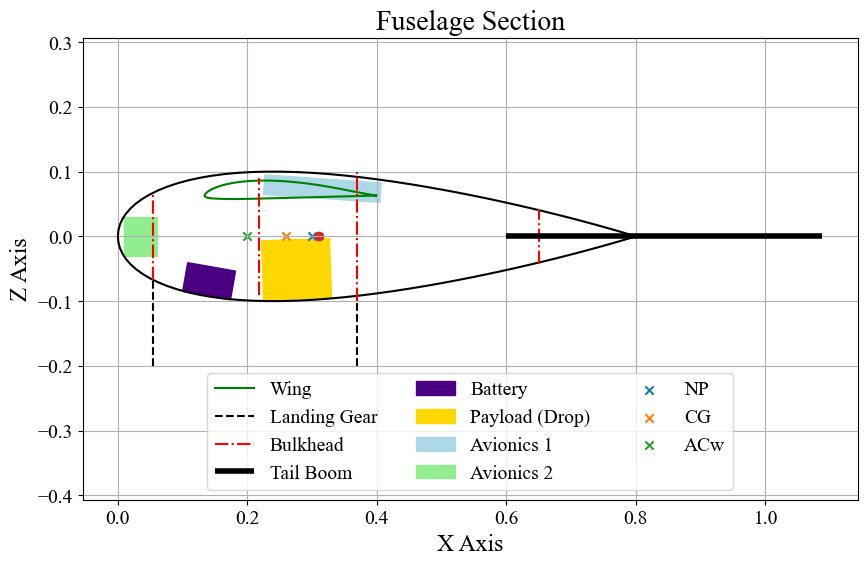

In [55]:
# Plotting to Visualise the Component Placement
import matplotlib.patches as patches

naca0025 = np.loadtxt('naca0025.dat')
naca0025 *= chord_fuselage


plt.figure(figsize=(10, 6))
plt.plot(naca0025[:, 0], naca0025[:, 1], c='k')
plt.plot(s7055[:, 0] + ACw - chord/4, s7055[:, 1] + 63e-3, c='g', label='Wing')
battery = patches.Rectangle((100e-3, -85e-3), 75e-3, 45e-3, angle=-10, label='Battery', facecolor='indigo', edgecolor='indigo')
payload = patches.Rectangle((225e-3, -98e-3), 105e-3, 91e-3, angle=2, label='Payload (Drop)', facecolor='gold', edgecolor='gold')
controller_avionics = patches.Rectangle((225e-3, 65e-3), 180e-3, 30e-3, angle=-4, label='Avionics 1', facecolor='lightblue', edgecolor='lightblue')
transmission_avionics = patches.Rectangle((10e-3, -30e-3), 50e-3, 60e-3, angle=0, label='Avionics 2', facecolor='lightgreen', edgecolor='lightgreen')

plt.vlines(x=[nose_lg, main_lg], ymin=[-200e-3, -200e-3] , ymax=[-67e-3, -90e-3], label='Landing Gear', colors='k', linestyles='--')
plt.vlines(x=[nose_lg, ACw + (0.3174 - 0.25)*chord, main_lg, 650e-3], ymin=[-67e-3, -90e-3, -100e-3, -42e-3] , ymax=[67e-3, 90e-3, 100e-3, 42e-3], label='Bulkhead', colors='red', linestyles='-.')

plt.hlines(y=0, xmin=600e-3, xmax=600e-3 + len_tailboom, label='Tail Boom', colors='k', linestyles='-', linewidths=4)

bulkhead_xloc = np.array([nose_lg, ACw + (0.3174 - 0.25)*chord, main_lg, 650e-3])

plt.gca().add_patch(battery)
plt.gca().add_patch(payload)
plt.gca().add_patch(controller_avionics)
plt.gca().add_patch(transmission_avionics)

plt.xlabel('X Axis')
plt.ylabel('Z Axis')
plt.title('Fuselage Section')

plt.scatter(NP, 0, label='NP', marker='x')
plt.scatter(CG, 0, label='CG', marker='x')
plt.scatter(ACw, 0, label='ACw', marker='x')
# plt.xlim(0, 800e-3)

plt.scatter(310e-3, 0e-3)
plt.axis('equal')
plt.grid()
plt.legend(loc='lower center', ncol=3)
plt.show()

In [56]:
bulkhead_xloc



array([0.055   , 0.217861, 0.37    , 0.65    ])

In [57]:
ACw + (0.3174 - 0.25)*chord

0.21786100000000003

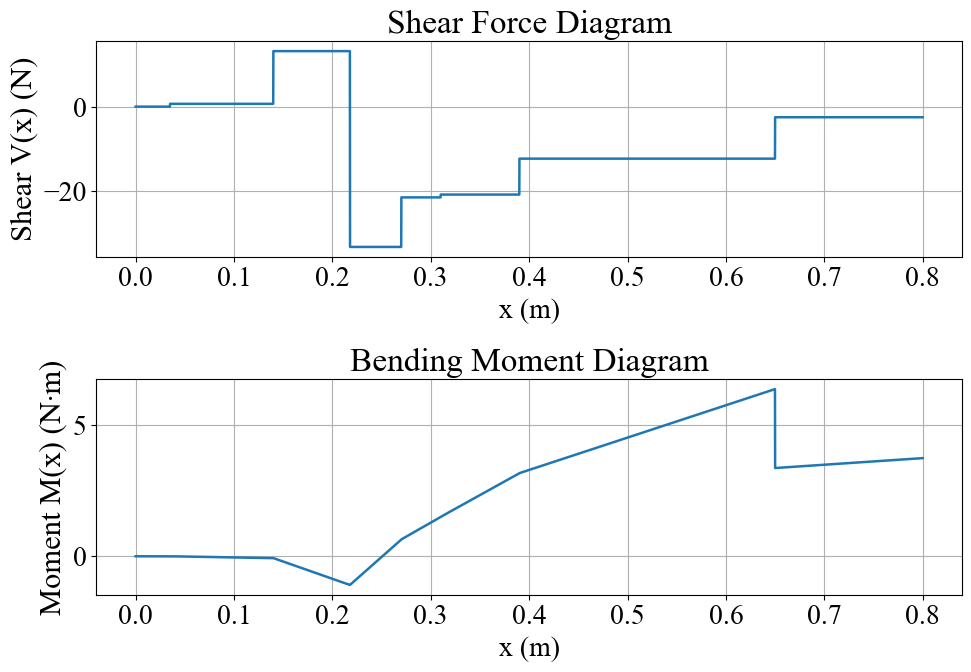

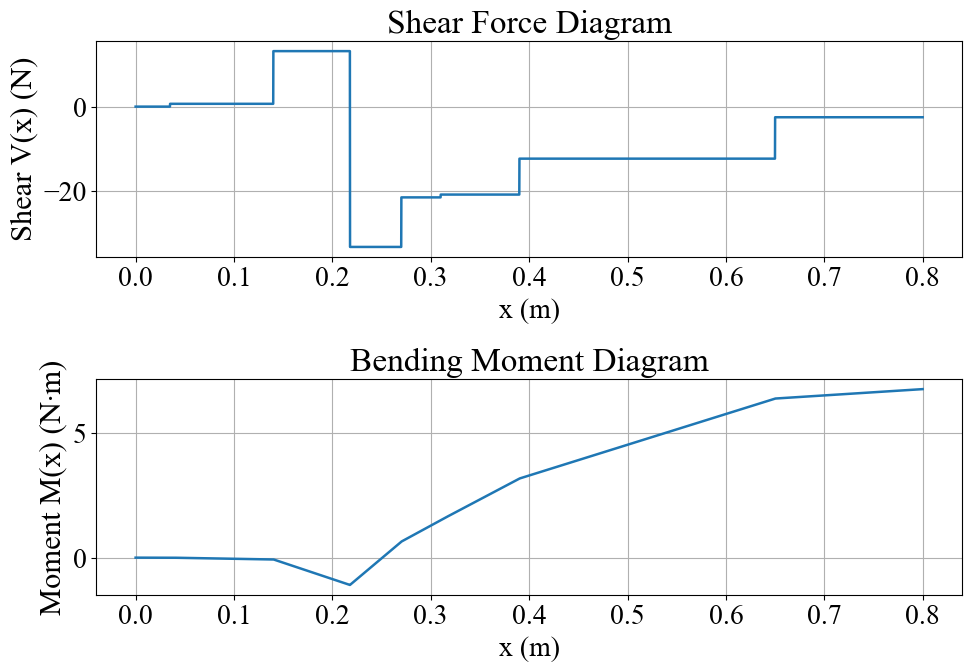

[0.055    0.217861 0.37     0.65    ]
Longeron is enough to withstand bending moment
0.28502725588672656
F_cr    = 2.463001e+05 Pa
tau_max = 1.242880e+03 Pa
Not Buckled

------ Results ------
V_max   = 33.3356 N
M_max   = 6.7685 N.m
I_skin  = 2.318375e-06 m^4
I_boom  = 4.000000e-04 m^4
I_req   = 8.416087e-08 m^4
I_xx    = 4.023184e-04 m^4
q_max   = 0.621440 N/m
tau_max = 1.242880e+03 Pa
Kss     = 7.309460
F_cr    = 2.463001e+05 Pa


In [58]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


def sfd_bmd_fuse(L, p_pos, p_mag, m_pos=None, m_mag=None, npts=5000):

    # Convert point-force inputs to 1D NumPy arrays
    p_pos = np.asarray(p_pos, dtype=float).flatten()
    p_mag = np.asarray(p_mag, dtype=float).flatten()

    # Handle point moments
    if m_pos is None:
        m_pos = np.array([])
        m_mag = np.array([])
    else:
        m_pos = np.asarray(m_pos, dtype=float).flatten()
        m_mag = np.asarray(m_mag, dtype=float).flatten()

    # Discretized x-coordinate
    x_grid = np.linspace(0, L, npts)

    # SHEAR FORCE DIAGRAM

    # True wherever point load position <= x
    ind = p_pos[:, np.newaxis] <= x_grid[np.newaxis, :]

    # Sum all point loads encountered
    V = -np.sum(
        p_mag[:, np.newaxis] * ind,
        axis=0
    )

    # BENDING MOMENT FROM POINT FORCES

    dx = x_grid[np.newaxis, :] - p_pos[:, np.newaxis]

    # Only loads to the left of x contribute
    dx[dx < 0] = 0

    M = np.sum(
        p_mag[:, np.newaxis] * dx,
        axis=0
    )

    # BENDING MOMENT FROM POINT MOMENTS

    if len(m_pos) > 0:

        # A point moment causes a step/jump in the BMD
        moment_ind = m_pos[:, np.newaxis] <= x_grid[np.newaxis, :]

        M += np.sum(
            m_mag[:, np.newaxis] * moment_ind,
            axis=0
        )


    # PLOT SFD AND BMD
    #plt.rcParams.update({'font.size': 20})

    fig, axes = plt.subplots(2, 1, figsize=(10, 7))
    font_size = 20
    # -------------------------
    # Shear Force Diagram
    # -------------------------

    axes[0].plot(x_grid, V, linewidth=1.8)

    axes[0].set_xlabel("x (m)", fontsize=font_size)
    axes[0].set_ylabel("Shear V(x) (N)",fontsize=font_size+2)
    axes[0].set_title("Shear Force Diagram", fontsize=font_size+4)
    axes[0].tick_params(axis='both', which='major', labelsize=font_size)
    axes[0].grid(True)

    # -------------------------
    # Bending Moment Diagram
    # -------------------------

    axes[1].plot(x_grid, M, linewidth=1.8)

    axes[1].set_xlabel("x (m)", fontsize=font_size)
    axes[1].set_ylabel("Moment M(x) (N·m)", fontsize=font_size+2)
    axes[1].set_title("Bending Moment Diagram", fontsize=font_size+4)
    axes[1].tick_params(axis='both', which='major', labelsize=font_size)
    axes[1].grid(True)

    plt.tight_layout()
    plt.savefig('sfd_bmd_fuse.png', dpi=300)
    plt.show()

    return x_grid, V, M


# EXAMPLE

L = 800e-3

tail_arm_tailboom_bulkhead = len_tailboom - 50e-3 - 0.75 * (chord_ht + chord_vt)/2

# Point forces
p_pos = [35e-3, 140e-3, ACw + (0.3174 - 0.25)*chord, 270e-3, 310e-3, 390e-3, 650e-3]
p_mag = [-W_transmission_avionics*g, -W_battery*g, Lw - W_spar_total*g, -W_payload*g, -W_controller_avionics*g, -W_fg_tb*g, Lt - W_tail_total*g]    # Note that Tail's Lift is Negative

# Point moments
m_pos = [650e-3]
m_mag = [(Lt - W_tail_total*g)*tail_arm_tailboom_bulkhead]    # SHould be a CW Moment (Negative)

x, V, M = sfd_bmd_fuse(
    L,
    p_pos,
    p_mag,
    m_pos,
    m_mag
)
x, V, M = sfd_bmd_fuse(
    L,
    p_pos,
    p_mag
)

V_max = np.max(np.abs(V))       # N
M_max = np.max(np.abs(M))       # N.m

# Calculating the Length of the Panels

naca0025_dl = np.linalg.norm(naca0025[:-1, :] - naca0025[1:, :], axis=1)


print(bulkhead_xloc)
idx_bk_u = np.zeros(n_bk, dtype=int)
fuselage_bk_panel = np.zeros(n_bk - 1)

for i in range(n_bk):
  idx_bk_u[i] = np.argmin(np.abs(naca0025[:, 0] - bulkhead_xloc[i]))
  # plt.scatter(naca0025[idx_bk_u[i], 0], naca0025[idx_bk_u[i], 1])

for i in range(len(fuselage_bk_panel)):
  fuselage_bk_panel[i] = np.sum(naca0025_dl[idx_bk_u[i+1]:idx_bk_u[i]])

# plt.axis('equal')
# plt.show()



h_f = 0.25*chord_fuselage # maximum height
b_f = 200e-3 # maximum width
t = 0.0005 # thickness of the plate

A = 20*t # longerons only at corners

I_skin = (1/12)*(b_f * h_f**3 - (b_f - t) * (h_f - 2*t)**3) #(h_f**4 / 12) - ((h_f - t)**4 / 12)
I_boom = 4 * A * (h_f/2)**2
# I_boom = 0

sig_yield = 95e6
FOS = n_fos * n_vn * n_fatigue * k_stress_conc_factor

sig_all = sig_yield / FOS

I_req = M_max * h_f / (2 * sig_all)

if I_req > I_skin + I_boom:
    print("Longeron is not enough to withstand bending moment of fuselage")
else:
    print("Longeron is enough to withstand bending moment")

# Shear Flow & F_cr Calculation of Fuselage

I_xx = I_skin + I_boom
# Maximum shear flow
q_max = ((2 * b_f / h_f) + 1)*(V_max * t * h_f**2) / (8 * I_xx) # at the midpoint of the side webs

# Maximum shear stress
tau_max = q_max / t # Pa

# 4 Bulkhead Sections

a = fuselage_bk_panel[2] # m, Test for all the Panels
print(a)
b = 0.2 # m, Maximum value for fuselage height or width is 200mm

E = 69e9
nu = 0.33

Ra = 1 # fixed support


Kss = 5.34 + 4 * (b / a)**2

F_cr = (
    Kss * np.pi**2 * E
    / (12 * (1 - nu**2))
) * (t / b)**2 * Ra # Pa

F_cr = F_cr / FOS

# Buckling Check
print(f"F_cr    = {F_cr:.6e} Pa")
print(f"tau_max = {tau_max:.6e} Pa")

if tau_max > F_cr:
    print("Buckled")
else:
    print("Not Buckled")

print("\n------ Results ------")
print(f"V_max   = {V_max:.4f} N")
print(f"M_max   = {M_max:.4f} N.m")
print(f"I_skin  = {I_skin:.6e} m^4")
print(f"I_boom  = {I_boom:.6e} m^4")
print(f"I_req   = {I_req:.6e} m^4")
print(f"I_xx    = {I_xx:.6e} m^4")
print(f"q_max   = {q_max:.6f} N/m")
print(f"tau_max = {tau_max:.6e} Pa")
print(f"Kss     = {Kss:.6f}")
print(f"F_cr    = {F_cr:.6e} Pa")


1.138


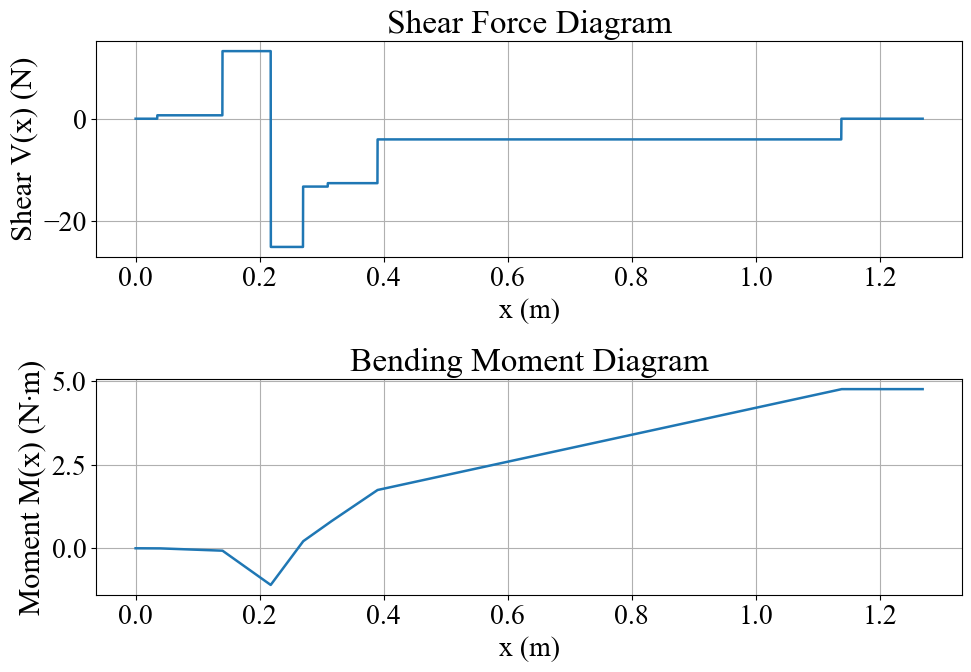

[0.055    0.217861 0.37     0.65    ]
Longeron is enough to withstand bending moment
0.28502725588672656
F_cr    = 2.463001e+05 Pa
tau_max = 9.324322e+02 Pa
Not Bukled

------ Results ------
V_max   = 25.0090 N
M_max   = 4.7607 N.m
I_skin  = 2.318375e-06 m^4
I_boom  = 4.000000e-04 m^4
I_req   = 5.919586e-08 m^4
I_xx    = 4.023184e-04 m^4
q_max   = 0.466216 N/m
tau_max = 9.324322e+02 Pa
Kss     = 7.309460
F_cr    = 2.463001e+05 Pa


In [59]:
tail_arm_tailboom_bulkhead = len_tailboom - 50e-3 - 0.75 * (chord_ht + chord_vt)/2
x_tail = 650e-3 + len_tailboom

L = x_tail + 0.75 * (chord_ht + chord_vt)/2

Weight = (W_transmission_avionics + W_battery + W_spar_total + W_payload + W_controller_avionics + W_fg_tb + W_tail_total)*g
Lw = Weight


print(x_tail)

p_pos = [35e-3, 140e-3, ACw + (0.3174 - 0.25)*chord, 270e-3, 310e-3, 390e-3, x_tail]
p_mag = [-W_transmission_avionics*g, -W_battery*g, Lw - W_spar_total*g, -W_payload*g, -W_controller_avionics*g, -W_fg_tb*g, - W_tail_total*g]    # Note that Tail's Lift is Negative

# x, V, M = sfd_bmd_fuse(
#     L,
#     p_pos,
#     p_mag,
#     m_pos,
#     m_mag
# )

x, V, M = sfd_bmd_fuse(
    L,
    p_pos,
    p_mag
)


V_max = np.max(np.abs(V))       # N
M_max = np.max(np.abs(M))       # N.m

# Calculating the Length of the Panels

naca0025_dl = np.linalg.norm(naca0025[:-1, :] - naca0025[1:, :], axis=1)


print(bulkhead_xloc)
idx_bk_u = np.zeros(n_bk, dtype=int)
fuselage_bk_panel = np.zeros(n_bk - 1)

for i in range(n_bk):
  idx_bk_u[i] = np.argmin(np.abs(naca0025[:, 0] - bulkhead_xloc[i]))
  # plt.scatter(naca0025[idx_bk_u[i], 0], naca0025[idx_bk_u[i], 1])

for i in range(len(fuselage_bk_panel)):
  fuselage_bk_panel[i] = np.sum(naca0025_dl[idx_bk_u[i+1]:idx_bk_u[i]])

# plt.axis('equal')
# plt.show()



h_f = 0.25*chord_fuselage # maximum height
b_f = 200e-3 # maximum width
t = 0.0005 # thickness of the plate

A = 20*t # longerons only at corners

I_skin = (1/12)*(b_f * h_f**3 - (b_f - t) * (h_f - 2*t)**3) #(h_f**4 / 12) - ((h_f - t)**4 / 12)
I_boom = 4 * A * (h_f/2)**2
# I_boom = 0

sig_yield = 95e6
FOS = n_fos * n_vn * n_fatigue * k_stress_conc_factor

sig_all = sig_yield / FOS

I_req = M_max * h_f / (2 * sig_all)

if I_req > I_skin + I_boom:
    print("Longeron is not enough to withstand bending moment of fuselage")
else:
    print("Longeron is enough to withstand bending moment")

# Shear Flow & F_cr Calculation of Fuselage

I_xx = I_skin + I_boom
# Maximum shear flow
q_max = ((2 * b_f / h_f) + 1)*(V_max * t * h_f**2) / (8 * I_xx) # at the midpoint of the side webs

# Maximum shear stress
tau_max = q_max / t # Pa

# 4 Bulkhead Sections

a = fuselage_bk_panel[2] # m, Test for all the Panels
print(a)
b = 0.2 # m, Maximum value for fuselage height or width is 200mm

E = 69e9
nu = 0.33

Ra = 1 # fixed support


Kss = 5.34 + 4 * (b / a)**2

F_cr = (
    Kss * np.pi**2 * E
    / (12 * (1 - nu**2))
) * (t / b)**2 * Ra # Pa

F_cr = F_cr / FOS

# Buckling Check
print(f"F_cr    = {F_cr:.6e} Pa")
print(f"tau_max = {tau_max:.6e} Pa")

if tau_max > F_cr:
    print("Buckled")
else:
    print("Not Bukled")

print("\n------ Results ------")
print(f"V_max   = {V_max:.4f} N")
print(f"M_max   = {M_max:.4f} N.m")
print(f"I_skin  = {I_skin:.6e} m^4")
print(f"I_boom  = {I_boom:.6e} m^4")
print(f"I_req   = {I_req:.6e} m^4")
print(f"I_xx    = {I_xx:.6e} m^4")
print(f"q_max   = {q_max:.6f} N/m")
print(f"tau_max = {tau_max:.6e} Pa")
print(f"Kss     = {Kss:.6f}")
print(f"F_cr    = {F_cr:.6e} Pa")

In [60]:
m_mag

[-3.0175326674894256]

In [61]:
Lw - W_spar_total

57.20453534323818

In [62]:
W_battery

1.276

In [63]:
print(idx_bk_u)
fuselage_bk_panel

[42 33 26 14]


array([0.162829  , 0.1679509 , 0.28502726])

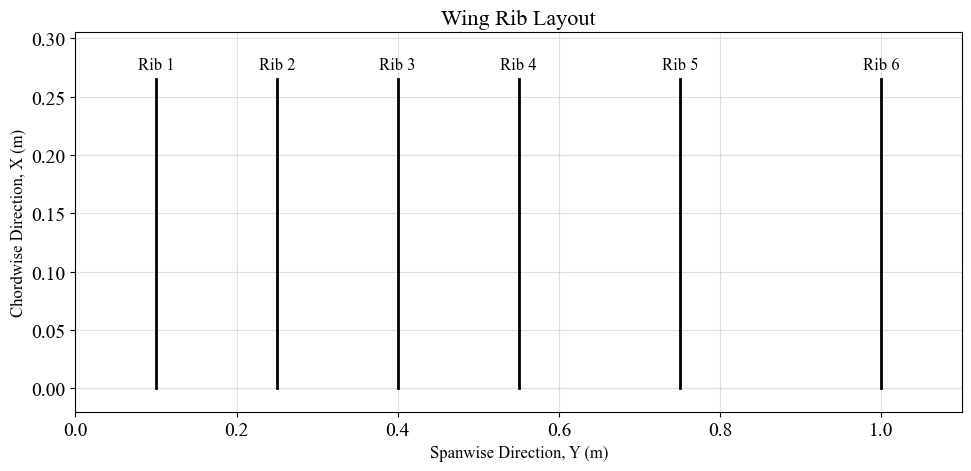

In [64]:
import matplotlib.pyplot as plt

# Rib station locations from the mid-plane (mm)
rib_stations = [100, 250, 400, 550, 750, 1000]

# Rib types
rib_types = [
    "Root",
    "Standard",
    "Standard",
    "Standard",
    "Standard",
    "Tip"
]

# Chord length (m) -- replace with your actual chord if needed
chord = 0.265

# Convert spanwise station from mm to m
rib_y = [y / 1000 for y in rib_stations]

# Plot
fig, ax = plt.subplots(figsize=(10, 5))

for i, (y, rib_type) in enumerate(zip(rib_y, rib_types), start=1):

    # Draw rib
    ax.plot(
        [y, y],
        [0, chord],
        color="black",
        linewidth=2
    )

    # Rib label
    ax.text(
        y,
        chord + 0.005,
        f"Rib {i}",
        ha="center",
        va="bottom",
        fontsize=12
    )

# Formatting
ax.set_title("Wing Rib Layout", fontsize=16)
ax.set_xlabel("Spanwise Direction, Y (m)", fontsize=12)
ax.set_ylabel("Chordwise Direction, X (m)", fontsize=12)

ax.set_xlim(0, 1.1)
ax.set_ylim(-0.02, chord + 0.04)

ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()


In [65]:
import matplotlib.font_manager as fm

for f in fm.fontManager.ttflist:
    if "Times" in f.name:
        print(f.name, f.fname)
        

Times New Roman /usr/share/fonts/truetype/msttcorefonts/times.ttf
Times New Roman /usr/share/fonts/truetype/msttcorefonts/timesbd.ttf
Times New Roman /usr/share/fonts/truetype/msttcorefonts/timesbi.ttf
Times New Roman /usr/share/fonts/truetype/msttcorefonts/Times_New_Roman_Bold.ttf
Times New Roman /usr/share/fonts/truetype/msttcorefonts/Times_New_Roman.ttf
Times New Roman /usr/share/fonts/truetype/msttcorefonts/Times_New_Roman_Bold_Italic.ttf
Times New Roman /usr/share/fonts/truetype/msttcorefonts/timesi.ttf
Times New Roman /usr/share/fonts/truetype/msttcorefonts/Times_New_Roman_Italic.ttf


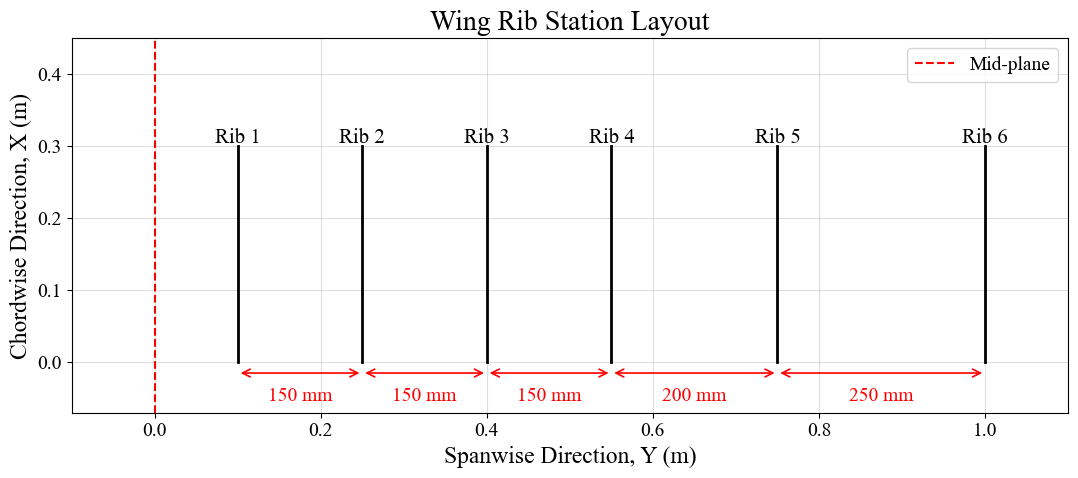

In [66]:
import matplotlib.pyplot as plt

# ==============================
# Global font settings
# ==============================
plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 20,
    "axes.labelsize": 17,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14
})
plt.rcParams["font.family"] = "Times New Roman" 

# Rib station locations (mm)
rib_stations = [100, 250, 400, 550, 750, 1000]

# Rib types
rib_types = [
    "Root",
    "Standard",
    "Standard",
    "Standard",
    "Standard",
    "Tip"
]

# Chord length (m)
chord = 0.30

# Convert to metres
rib_y = [y / 1000 for y in rib_stations]

fig, ax = plt.subplots(figsize=(11, 5))

# Mid-plane at y = 0
ax.axvline(
    x=0,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label="Mid-plane"
)

# Draw ribs
for i, (y, rib_type) in enumerate(zip(rib_y, rib_types), start=1):

    ax.plot(
        [y, y],
        [0, chord],
        color="black",
        linewidth=2
    )

    ax.text(
        y,
        chord + 0.005,
        f"Rib {i}",
        ha="center",
        fontsize=15
    )

# Add spacing dimensions
for i in range(1, len(rib_y)):
    y1 = rib_y[i - 1]
    y2 = rib_y[i]
    y_mid = (y1 + y2) / 2

    spacing = rib_stations[i] - rib_stations[i - 1]

    ax.annotate(
        "",
        xy=(y2, -0.015),
        xytext=(y1, -0.015),
        arrowprops=dict(
            arrowstyle="<->",
            color="red",
            lw=1.2
        )
    )

    ax.text(
        y_mid,
        -0.035,
        f"{spacing} mm",
        ha="center",
        va="top",
        color="red",
        fontsize=14
    )

# Formatting
ax.set_title("Wing Rib Station Layout", fontsize=20)
ax.set_xlabel("Spanwise Direction, Y (m)", fontsize=17)
ax.set_ylabel("Chordwise Direction, X (m)", fontsize=17)

ax.set_xlim(-0.1, 1.1)
ax.set_ylim(-0.07, chord + 0.15)

ax.grid(True, alpha=0.4)

# Legend
ax.legend(fontsize=14)

plt.tight_layout()
plt.savefig('wing_rib_layout.pdf', dpi=300)
plt.show()
